# <center>Linear Regression From Scratch<center>

## Table of Contents
1. Closed form
2. Gradient descent
3. Stochastic gradient descent
4. Mini batch gradient descent
5. Singular Value Decomposition (SVD)
6. Ridge
7. Lasso
8. Polynomial regression
9. Time comparison

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from linear_regression import Linear_Regression
from metrics import MSE, RMSE

# importing dataset
path = '../data/happiness2016.csv'

df = pd.read_csv(path)

#### Checking data

In [2]:
df.head()

,Country,Region,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Denmark,Western Europe,1,7.526,7.460,7.592,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171,2.73939
1,Switzerland,Western Europe,2,7.509,7.428,7.590,1.52733,1.14524,0.86303,0.58557,0.41203,0.28083,2.69463
2,Iceland,Western Europe,3,7.501,7.333,7.669,1.42666,1.18326,0.86733,0.56624,0.14975,0.47678,2.83137
3,Norway,Western Europe,4,7.498,7.421,7.575,1.57744,1.12690,0.79579,0.59609,0.35776,0.37895,2.66465
4,Finland,Western Europe,5,7.413,7.351,7.475,1.40598,1.13464,0.81091,0.57104,0.41004,0.25492,2.82596


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        157 non-null    str    
 1   Region                         157 non-null    str    
 2   Happiness Rank                 157 non-null    int64  
 3   Happiness Score                157 non-null    float64
 4   Lower Confidence Interval      157 non-null    float64
 5   Upper Confidence Interval      157 non-null    float64
 6   Economy (GDP per Capita)       157 non-null    float64
 7   Family                         157 non-null    float64
 8   Health (Life Expectancy)       157 non-null    float64
 9   Freedom                        157 non-null    float64
 10  Trust (Government Corruption)  157 non-null    float64
 11  Generosity                     157 non-null    float64
 12  Dystopia Residual              157 non-null    float64
dtypes

---

### Dataset Description

Dataset represents factors that have more or less influence on people's happiness in 157 countries in 2015. Each row corresponds to one country.

* **Country** – country name
* **Region** – region of the country
* **Happiness Rank** – country's rank according to the happiness score
* **Happiness Score** – average happiness score (0–10)
* **Lower Confidence Interval** – lower bound of the confidence interval for the happiness score
* **Upper Confidence Interval** – upper bound of the confidence interval for the happiness score
* **Economy (GDP per Capita)** – GDP contribution to the happiness score
* **Family** – family support contribution to the score
* **Health (Life Expectancy)** – life expectancy contribution to the score
* **Freedom** – feeling of freedom contribution to the score
* **Trust (Government Corruption)** – perception of corruption contribution to the score
* **Generosity** – generosity contribution to the score
* **Dystopia Residual** – difference between predicted and observed happiness not explained by other factors

#### Visualizing data

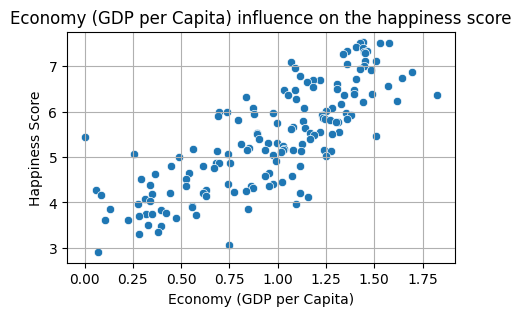

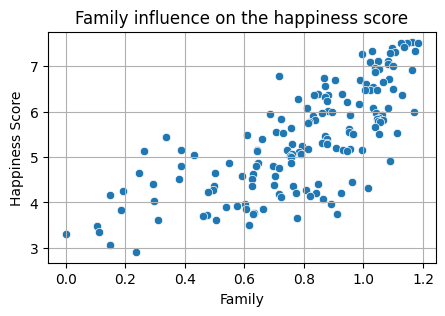

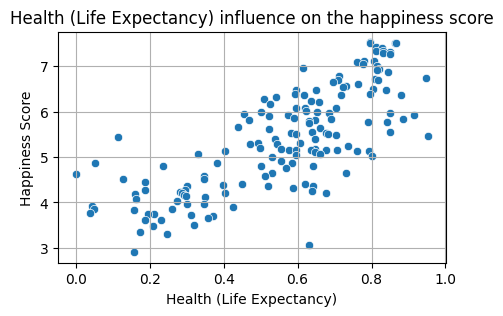

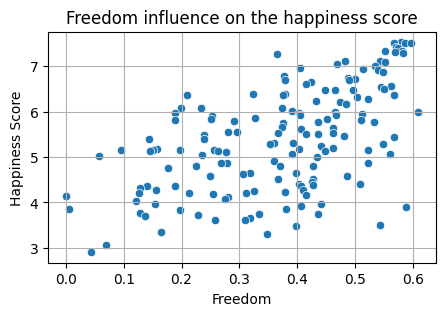

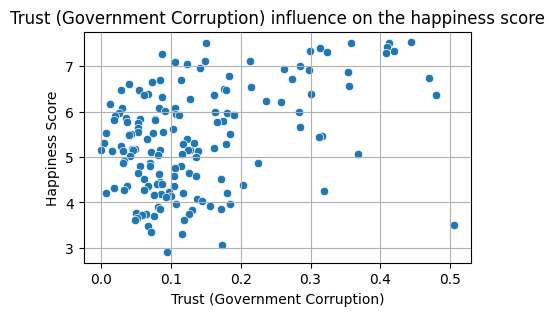

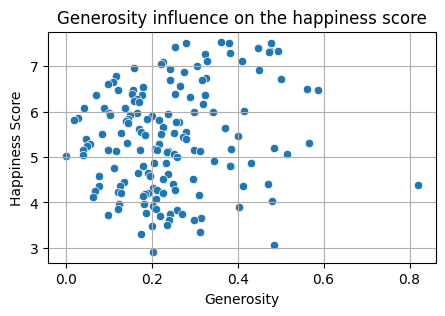

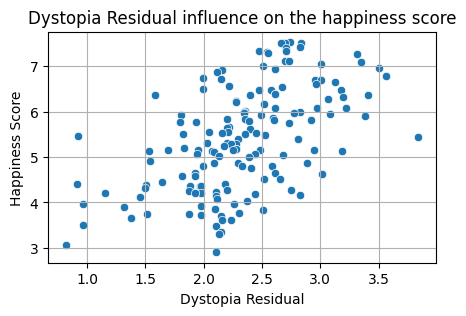

In [4]:
features = [
    'Economy (GDP per Capita)',
    'Family', 
    'Health (Life Expectancy)', 
    'Freedom',
    'Trust (Government Corruption)', 
    'Generosity',
    'Dystopia Residual'
]

for feature in features:
    plt.figure(figsize=(5, 3))
    sns.scatterplot(data=df, x=feature, y='Happiness Score')
    plt.grid(True)
    plt.title(f'{feature} influence on the happiness score')
    plt.show()

---

### **Closed form**

Error:
0.6972626334828966
Final function:
y = [2.18686322]X + 3.296180041308007
Error:
0.00029323944326990363
Final function:
y = [0.99999088 1.00002422 0.99985263 1.00016829 0.99970066 1.00017439
 0.99994759]X + 0.0001357357434505694


Text(0, 0.5, 'Happiness Score')

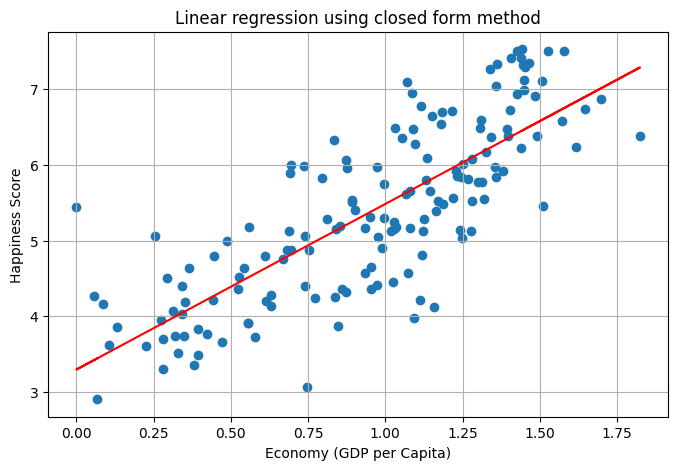

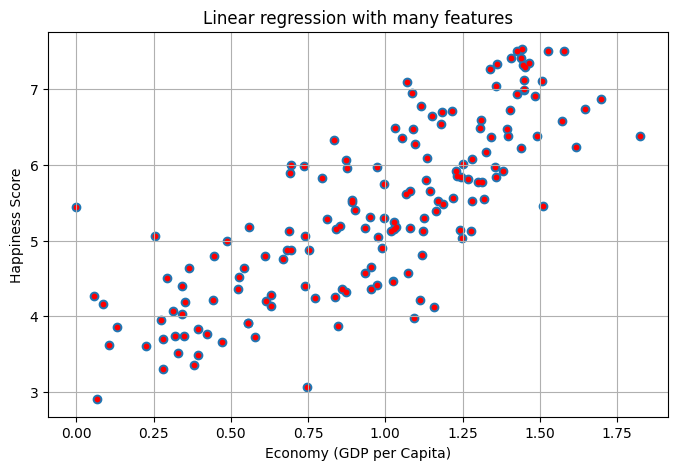

In [5]:
from closed_form import Linear_Regression_Closed_Form

X = df['Economy (GDP per Capita)'].to_numpy()
y = df['Happiness Score'].to_numpy()

closed_form = Linear_Regression_Closed_Form()
closed_form.fit(X, y)

y_pred = closed_form.predict(X)

print(f'Error:\n{RMSE(y, y_pred)}')
print(f'Final function:\ny = {closed_form.weights}X + {closed_form.bias}')

plt.figure(figsize=(8, 5))
plt.scatter(X, y, label='Data')
plt.plot(X, y_pred, color='red', label='Closed form')
plt.grid(True)
plt.title('Linear regression using closed form method')
plt.xlabel('Economy (GDP per Capita)')
plt.ylabel('Happiness Score')

X = df[features].to_numpy()
y = df['Happiness Score'].to_numpy()

closed_form = Linear_Regression_Closed_Form()
closed_form.fit(X, y)

y_pred = closed_form.predict(X)

print(f'Error:\n{RMSE(y, y_pred)}')
print(f'Final function:\ny = {closed_form.weights}X + {closed_form.bias}')

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], y, label='Data')
plt.scatter(X[:, 0], y_pred, color='red', s=10, label='Prediction')
plt.grid(True)
plt.title('Linear regression with many features')
plt.xlabel('Economy (GDP per Capita)')
plt.ylabel('Happiness Score')

---

### **Gradient descent**

RMSE: [5.24634127]
RMSE: [1.91015983]
RMSE: [0.96927437]
RMSE: [0.79493786]
RMSE: [0.77257452]
RMSE: [0.76989789]
RMSE: [0.76949874]
RMSE: [0.76936177]
RMSE: [0.76925766]
RMSE: [0.76916025]
RMSE: [0.76906649]
RMSE: [0.76897593]
RMSE: [0.76888843]
RMSE: [0.76880388]
RMSE: [0.76872217]
RMSE: [0.76864323]
RMSE: [0.76856694]
RMSE: [0.76849323]
RMSE: [0.768422]
RMSE: [0.76835317]
RMSE: [0.76828667]
RMSE: [0.76822241]
RMSE: [0.76816032]
RMSE: [0.76810032]
RMSE: [0.76804235]
RMSE: [0.76798633]
RMSE: [0.7679322]
RMSE: [0.7678799]
RMSE: [0.76782937]
RMSE: [0.76778054]
RMSE: [0.76773336]
RMSE: [0.76768777]
RMSE: [0.76764372]
RMSE: [0.76760116]
RMSE: [0.76756003]
RMSE: [0.76752029]
RMSE: [0.7674819]
RMSE: [0.7674448]
RMSE: [0.76740896]
RMSE: [0.76737432]
RMSE: [0.76734085]
RMSE: [0.76730852]
RMSE: [0.76727728]
RMSE: [0.76724709]
RMSE: [0.76721792]
RMSE: [0.76718974]
RMSE: [0.76716251]
RMSE: [0.7671362]
RMSE: [0.76711077]
RMSE: [0.76708621]
RMSE: [0.76706248]
RMSE: [0.76703954]
RMSE: [0.76701739]


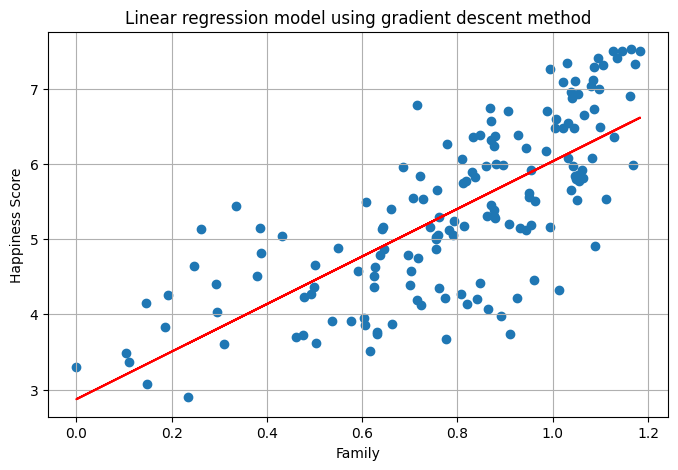

In [6]:
from gradient_descent import Linear_Regression_Gradient

X = df['Family'].to_numpy()
y = df['Happiness Score'].to_numpy()

gradient_descent = Linear_Regression_Gradient()

gradient_descent.fit(X, y, max_iters=1000, lr=0.2, stats=True)
y_pred = gradient_descent.predict(X)

print(f'Final function:\ny = {gradient_descent.weights}x + {gradient_descent.bias}')

plt.figure(figsize=(8, 5))
plt.scatter(X, y, label='Data')
plt.plot(X, y_pred, color='red', label='Gradient descent')
plt.xlabel('Family')
plt.ylabel('Happiness Score')
plt.title('Linear regression model using gradient descent method')
plt.grid()

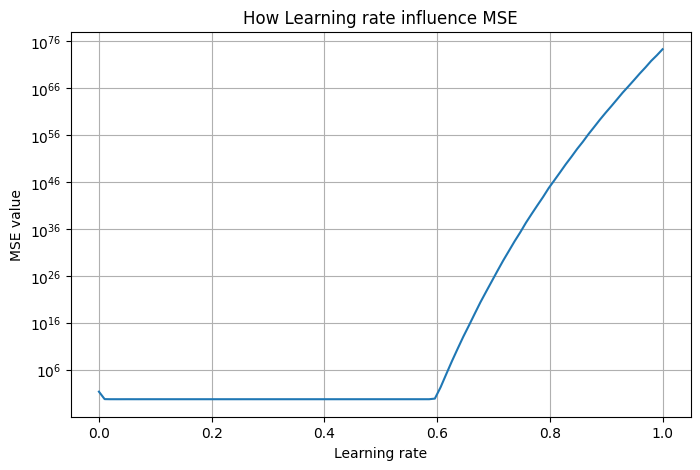

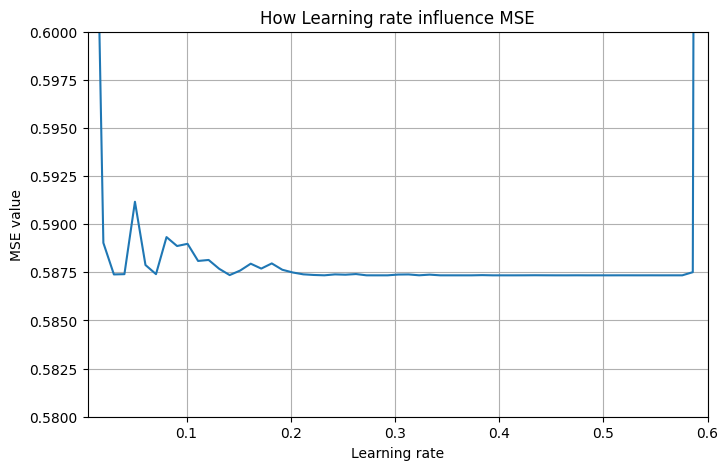

In [7]:
# === Learning rate test ===
learning_rate = np.linspace(0, 1, 100)
errors = []

for alpha in learning_rate:
    lr_test = Linear_Regression_Gradient()
    gradient_descent.fit(X, y, max_iters=100, lr=alpha, stats=False)
    y_pred = gradient_descent.predict(X)

    errors.append(MSE(y, y_pred))

plt.figure(figsize=(8, 5))
plt.plot(learning_rate, errors)
plt.yscale('log')
plt.xlabel('Learning rate')
plt.ylabel('MSE value')
plt.title('How Learning rate influence MSE')
plt.grid()

plt.figure(figsize=(8, 5))
plt.plot(learning_rate, errors)
plt.xlim(0.005, 0.6)
plt.ylim(0.58, 0.6)
plt.xlabel('Learning rate')
plt.ylabel('MSE value')
plt.title('How Learning rate influence MSE')
plt.grid()


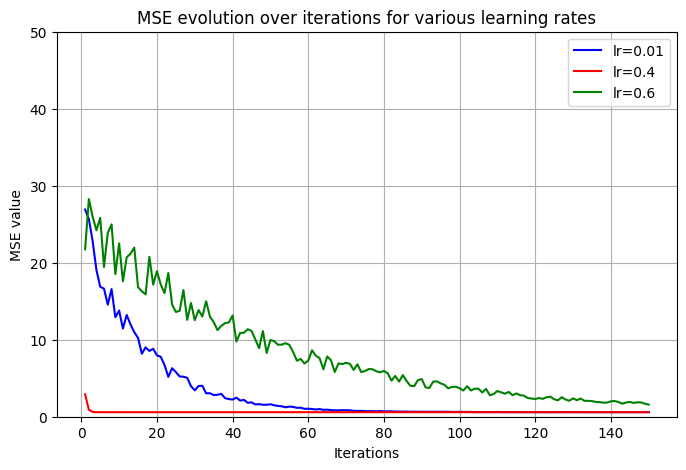

In [8]:
# === Iteration test ===
iterations = np.linspace(1, 150, 150, dtype=int)
learning_rate = [0.01, 0.4, 0.6]

errors = []
for alpha in learning_rate:
    error = []
    for iter in iterations:
        iter_test = Linear_Regression_Gradient()
        gradient_descent.fit(X, y, max_iters=iter, lr=alpha, stats=False)
        y_pred = gradient_descent.predict(X)

        error.append(MSE(y, y_pred))
    errors.append(error)


plt.figure(figsize=(8, 5))
plt.plot(iterations, errors[0], color='blue', label='lr=0.01')
plt.plot(iterations, errors[1], color='red', label='lr=0.4')
plt.plot(iterations, errors[2], color ='green', label='lr=0.6')
plt.ylim(0, 50)
plt.xlabel('Iterations')
plt.ylabel('MSE value')
plt.title('MSE evolution over iterations for various learning rates')
plt.legend()
plt.grid()


---

### **Stochastic gradient descent**

RMSE: [1.05524599]
RMSE: [0.18898043]
RMSE: [0.71171335]
RMSE: [0.89721755]
RMSE: [0.48516241]
RMSE: [0.56968532]
RMSE: [0.20087911]
RMSE: [0.71257049]
RMSE: [0.30640863]
RMSE: [0.6746717]
RMSE: [0.57345545]
RMSE: [0.99806511]
RMSE: [0.73762228]
RMSE: [0.45522132]
RMSE: [0.59617608]
RMSE: [0.96162924]
RMSE: [0.53544211]
RMSE: [0.08513265]
RMSE: [0.82269612]
RMSE: [0.05120384]
RMSE: [0.42529423]
RMSE: [1.48436497]
RMSE: [0.46325125]
RMSE: [0.02373481]
RMSE: [0.13934453]
RMSE: [0.83303571]
RMSE: [0.31920134]
RMSE: [0.39114878]
RMSE: [1.44998764]
RMSE: [0.01028575]
RMSE: [0.03310289]
RMSE: [0.44659073]
RMSE: [0.46860297]
RMSE: [0.81279215]
RMSE: [0.40687791]
RMSE: [0.55156653]
RMSE: [0.02359628]
RMSE: [0.20425038]
RMSE: [0.76598781]
RMSE: [0.79363424]
RMSE: [0.77864964]
RMSE: [0.97067946]
RMSE: [0.62638756]
RMSE: [1.15350641]
RMSE: [0.8695313]
RMSE: [0.25366751]
RMSE: [1.1556535]
RMSE: [0.62303808]
RMSE: [0.53052825]
RMSE: [0.32463012]
RMSE: [0.15748107]
RMSE: [0.62019332]
RMSE: [1.534136

Text(0.5, 1.0, 'Linear regression model using stochastic gradient descent method')

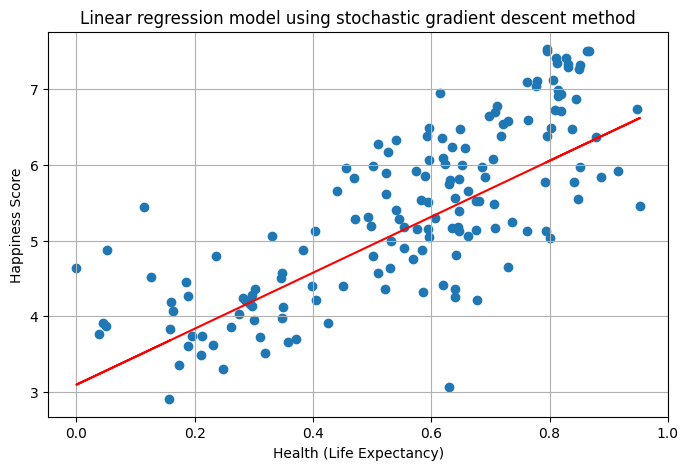

In [9]:
from stochastic_gd import Linear_Regression_Stochastic_GD

X = df['Health (Life Expectancy)'].to_numpy()
y = df['Happiness Score'].to_numpy()

stochastic = Linear_Regression_Stochastic_GD()
stochastic.fit(X, y, max_iters=100, lr=0.02, stats=True)

y_pred = stochastic.predict(X)

print(f'Final function\ny = {stochastic.weights}x + {stochastic.bias}')

plt.figure(figsize=(8, 5))
plt.scatter(X, y, label='Data')
plt.plot(X, y_pred, color='red', label='Stochastic gradient descent')
plt.grid()
plt.xlabel('Health (Life Expectancy)')
plt.ylabel('Happiness Score')
plt.title('Linear regression model using stochastic gradient descent method')

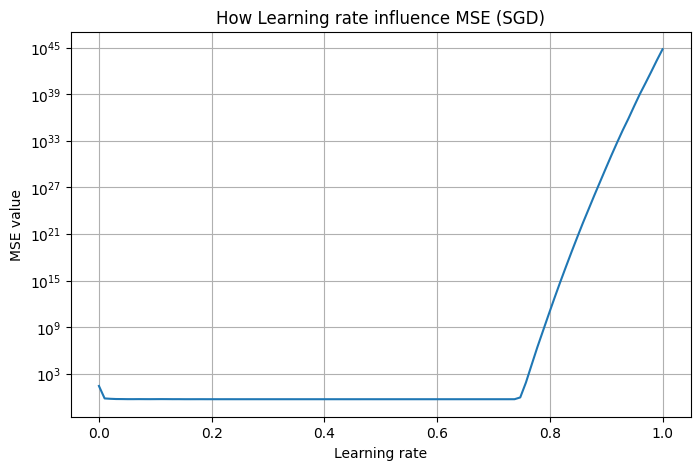

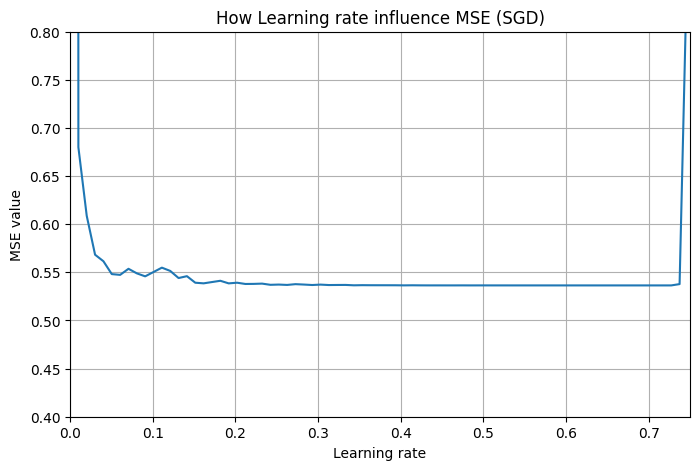

In [10]:
# === Learning rate test ===
learning_rate = np.linspace(0, 1, 100)
errors = []

for alpha in learning_rate:
    lr_test = Linear_Regression_Stochastic_GD()
    gradient_descent.fit(X, y, max_iters=100, lr=alpha, stats=False)
    y_pred = gradient_descent.predict(X)

    errors.append(MSE(y, y_pred))

plt.figure(figsize=(8, 5))
plt.plot(learning_rate, errors)
plt.yscale('log')
plt.xlabel('Learning rate')
plt.ylabel('MSE value')
plt.title('How Learning rate influence MSE (SGD)')
plt.grid()

plt.figure(figsize=(8, 5))
plt.plot(learning_rate, errors)
plt.xlim(0, 0.75)
plt.ylim(0.4, 0.8)
plt.xlabel('Learning rate')
plt.ylabel('MSE value')
plt.title('How Learning rate influence MSE (SGD)')
plt.grid()

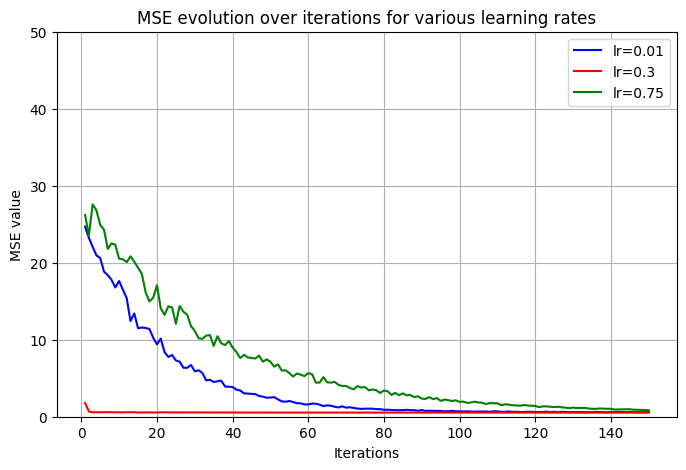

In [11]:
# === Iteration test ===
iterations = np.linspace(1, 150, 150, dtype=int)
learning_rate = [0.01, 0.3, 0.75]

errors = []
for alpha in learning_rate:
    error = []
    for iter in iterations:
        iter_test = Linear_Regression_Stochastic_GD()
        gradient_descent.fit(X, y, max_iters=iter, lr=alpha, stats=False)
        y_pred = gradient_descent.predict(X)

        error.append(MSE(y, y_pred))
    errors.append(error)


plt.figure(figsize=(8, 5))
plt.plot(iterations, errors[0], color='blue', label=f'lr={learning_rate[0]}')
plt.plot(iterations, errors[1], color='red', label=f'lr={learning_rate[1]}')
plt.plot(iterations, errors[2], color ='green', label=f'lr={learning_rate[2]}')
plt.ylim(0, 50)
plt.xlabel('Iterations')
plt.ylabel('MSE value')
plt.title('MSE evolution over iterations for various learning rates')
plt.legend()
plt.grid()


---

### **Mini batch**

RMSE: [1.01321833]
RMSE: [0.97750177]
RMSE: [0.93523187]
RMSE: [1.01546318]
RMSE: [1.11199195]
RMSE: [1.07463897]
RMSE: [0.82837013]
RMSE: [0.78032612]
RMSE: [0.86342738]
RMSE: [0.97820119]
RMSE: [1.0214649]
RMSE: [1.04794837]
RMSE: [1.11483286]
RMSE: [0.93704809]
RMSE: [0.98124245]
RMSE: [0.92926568]
RMSE: [0.88475677]
RMSE: [1.08105595]
RMSE: [0.86744863]
RMSE: [0.90165957]
RMSE: [0.88689396]
RMSE: [1.00008509]
RMSE: [1.09581581]
RMSE: [1.00378942]
RMSE: [1.05331499]
RMSE: [1.10452658]
RMSE: [1.09041565]
RMSE: [0.98181306]
RMSE: [0.87463401]
RMSE: [0.93570679]
RMSE: [0.9642986]
RMSE: [0.88695164]
RMSE: [0.97784002]
RMSE: [0.8985679]
RMSE: [0.77255054]
RMSE: [0.91135668]
RMSE: [0.96236357]
RMSE: [0.88746592]
RMSE: [0.84614389]
RMSE: [0.85942371]
RMSE: [0.86842879]
RMSE: [0.89352948]
RMSE: [0.83859927]
RMSE: [0.93428032]
RMSE: [1.01536417]
RMSE: [0.96612837]
RMSE: [0.84281911]
RMSE: [0.77819478]
RMSE: [0.99358976]
RMSE: [1.01041811]
RMSE: [1.00478913]
RMSE: [0.85983616]
RMSE: [0.993277

Text(0.5, 1.0, 'Linear regression using mini batch gradient descent method')

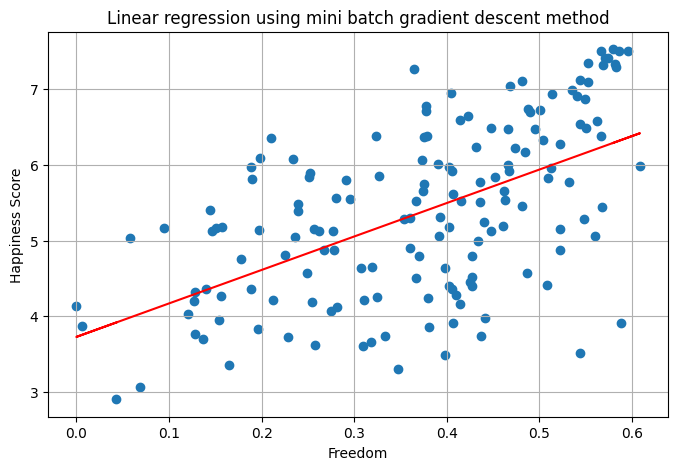

In [12]:
from mini_batch_gd import Linear_Regression_Mini_Batch

X = df['Freedom'].to_numpy()
y = df['Happiness Score'].to_numpy()

mini_batch = Linear_Regression_Mini_Batch()
mini_batch.fit(X, y, max_iters=100, lr=0.3, stats=True)

y_pred = mini_batch.predict(X)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, label='Data')
plt.plot(X, y_pred, color='red', label='Mini batch gradient descent')
plt.grid()
plt.xlabel('Freedom')
plt.ylabel('Happiness Score')
plt.title('Linear regression using mini batch gradient descent method')

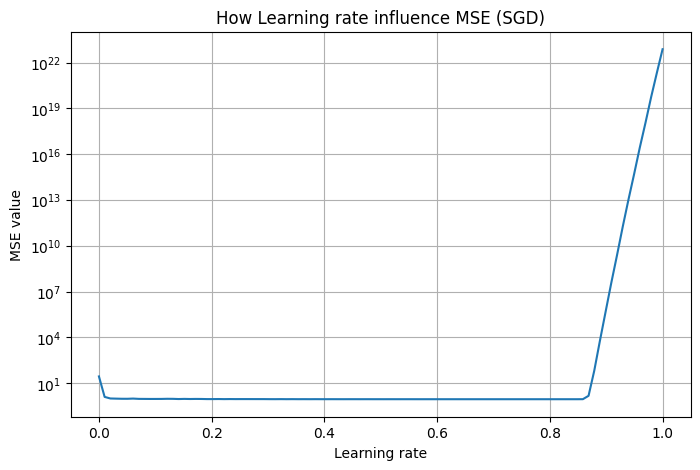

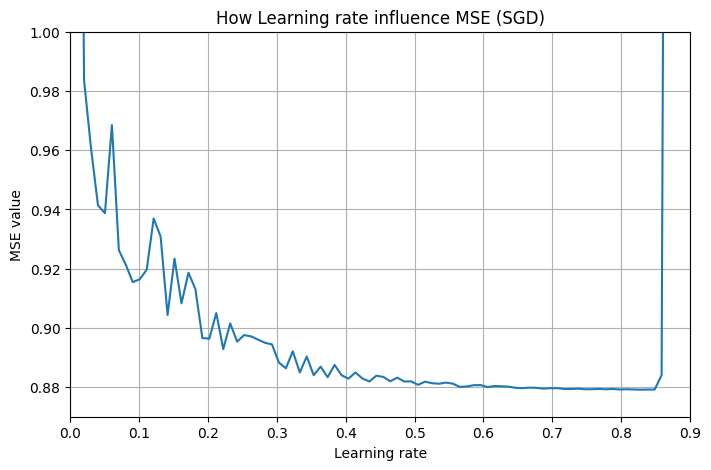

In [13]:
# === Learning rate test ===
learning_rate = np.linspace(0, 1, 100)
errors = []

for alpha in learning_rate:
    lr_test = Linear_Regression_Mini_Batch()
    gradient_descent.fit(X, y, max_iters=100, lr=alpha, stats=False)
    y_pred = gradient_descent.predict(X)

    errors.append(MSE(y, y_pred))

plt.figure(figsize=(8, 5))
plt.plot(learning_rate, errors)
plt.yscale('log')
plt.xlabel('Learning rate')
plt.ylabel('MSE value')
plt.title('How Learning rate influence MSE (SGD)')
plt.grid()

plt.figure(figsize=(8, 5))
plt.plot(learning_rate, errors)
plt.xlim(0, 0.9)
plt.ylim(0.87, 1)
plt.xlabel('Learning rate')
plt.ylabel('MSE value')
plt.title('How Learning rate influence MSE (SGD)')
plt.grid()

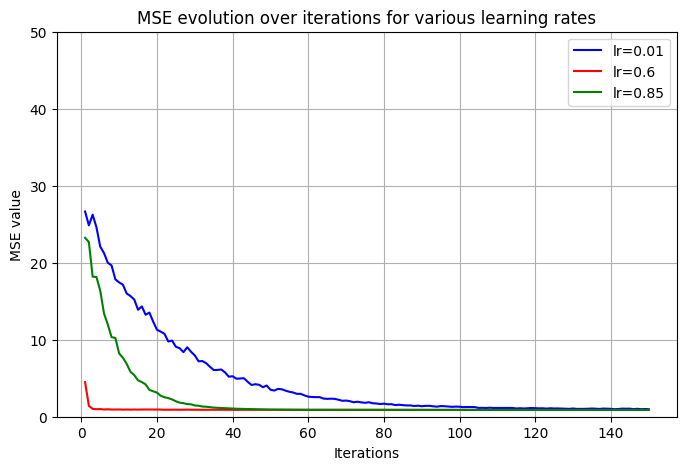

In [14]:
# === Iteration test ===
iterations = np.linspace(1, 150, 150, dtype=int)
learning_rate = [0.01, 0.6, 0.85]

errors = []
for alpha in learning_rate:
    error = []
    for iter in iterations:
        iter_test = Linear_Regression_Mini_Batch()
        gradient_descent.fit(X, y, max_iters=iter, lr=alpha, stats=False)
        y_pred = gradient_descent.predict(X)

        error.append(MSE(y, y_pred))
    errors.append(error)


plt.figure(figsize=(8, 5))
plt.plot(iterations, errors[0], color='blue', label=f'lr={learning_rate[0]}')
plt.plot(iterations, errors[1], color='red', label=f'lr={learning_rate[1]}')
plt.plot(iterations, errors[2], color ='green', label=f'lr={learning_rate[2]}')
plt.ylim(0, 50)
plt.xlabel('Iterations')
plt.ylabel('MSE value')
plt.title('MSE evolution over iterations for various learning rates')
plt.legend()
plt.grid()

---

### **Singular Value Decomposition (SVD)**

Final RMSE: [1.04201095]
Final Function: y = [[4.13362939]]x + [4.8132991]


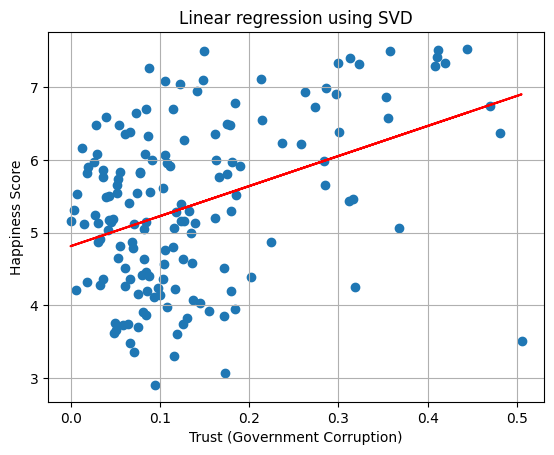

In [15]:
from svd import Linear_Regression_SVD

X = df['Trust (Government Corruption)'].to_numpy()
y = df['Happiness Score'].to_numpy()

svd = Linear_Regression_SVD()
svd.fit(X, y)

y_pred = svd.predict(X)

print(f'Final RMSE: {RMSE(y, y_pred)}')
print(f'Final Function: y = {svd.weights}x + {svd.bias}')
plt.scatter(X, y, label='Data')
plt.plot(X, y_pred, color='red', label='SVD')
plt.xlabel('Trust (Government Corruption)')
plt.ylabel('Happiness Score')
plt.title('Linear regression using SVD')
plt.grid()

Closed Form
Final RMSE:
0.6972626334828966
Final function:
y = [2.18686322]X + 3.296180041308007
SVD
Final RMSE:
[0.69726263]
Final function:
y = [[2.18686322]]X + [3.29618004]


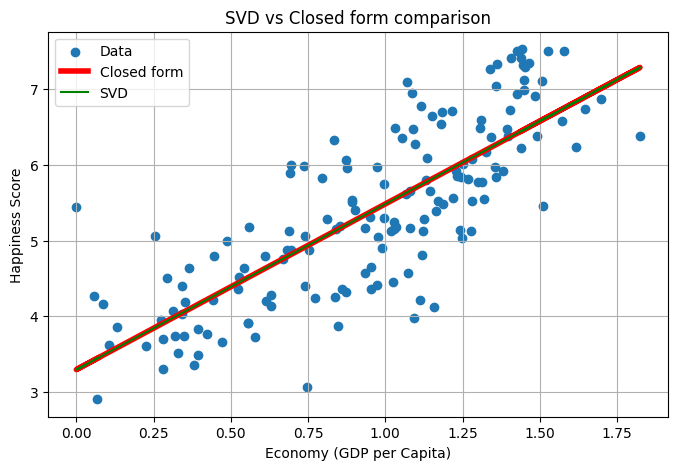

In [16]:
# SVD vs Closed form comparison

X = df['Economy (GDP per Capita)'].to_numpy()
y = df['Happiness Score'].to_numpy()

closed_form = Linear_Regression_Closed_Form()
closed_form.fit(X, y)

svd = Linear_Regression_SVD()
svd.fit(X, y)

y_cf = closed_form.predict(X)
y_svd = svd.predict(X)

print('Closed Form')
print(f'Final RMSE:\n{RMSE(y, y_cf)}')
print(f'Final function:\ny = {closed_form.weights}X + {closed_form.bias}')


print('SVD')
print(f'Final RMSE:\n{RMSE(y, y_svd)}')
print(f'Final function:\ny = {svd.weights}X + {svd.bias}')

plt.figure(figsize=(8, 5))
plt.scatter(X, y, label='Data')
plt.plot(X, y_cf, color='red', linewidth=4, label='Closed form')
plt.plot(X, y_svd, color='green', label='SVD')
plt.grid(True)
plt.title('SVD vs Closed form comparison')
plt.xlabel('Economy (GDP per Capita)')
plt.ylabel('Happiness Score')
plt.legend()


---

### **Ridge**

Final RMSE:
[0.6974607]
Final function:
y = [[2.14645055]]X + [3.33472887]


Text(0, 0.5, 'Happiness Score')

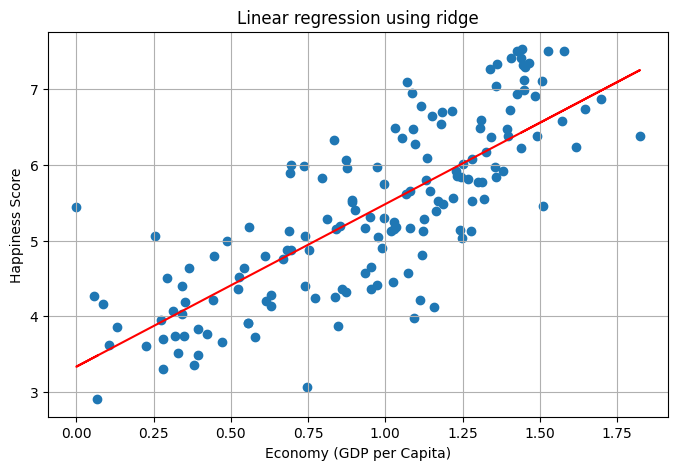

In [17]:
from ridge import Linear_Regression_Ridge

X = df['Economy (GDP per Capita)'].to_numpy()
y = df['Happiness Score'].to_numpy()

ridge = Linear_Regression_Ridge()
ridge.fit(X, y, alpha=0.5)

y_pred = ridge.predict(X)

print(f'Final RMSE:\n{RMSE(y, y_pred)}')
print(f'Final function:\ny = {ridge.weights}X + {ridge.bias}')

plt.figure(figsize=(8, 5))
plt.scatter(X, y, label='Data')
plt.plot(X, y_pred, color='red', label='Closed form')
plt.grid(True)
plt.title('Linear regression using ridge')
plt.xlabel('Economy (GDP per Capita)')
plt.ylabel('Happiness Score')

RMSE for alpha=0: [0.69726263]
RMSE for alpha=0.1: [0.6972708]
RMSE for alpha=1: [0.69802612]
RMSE for alpha=5: [0.71167658]
RMSE for alpha=10: [0.73939641]
RMSE for alpha=50: [0.91171945]
RMSE for alpha=100: [0.99561029]


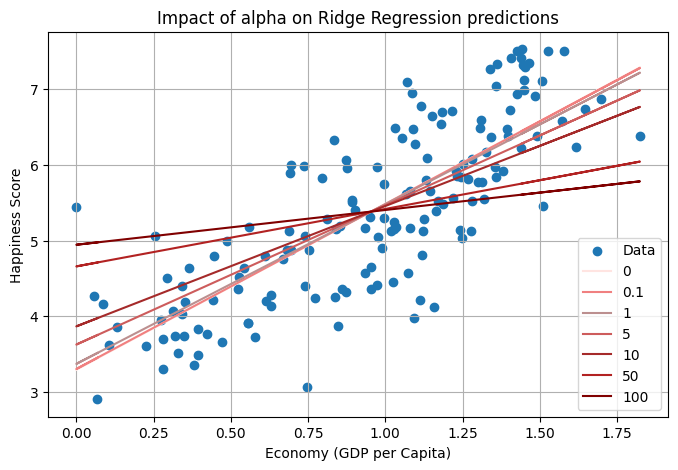

In [18]:
# === Alpha test ===
X = df['Economy (GDP per Capita)'].to_numpy()
y = df['Happiness Score'].to_numpy()

alphas = [0, 0.1, 1, 5, 10, 50, 100]
colors = [
    'mistyrose',
    'lightcoral',
    'rosybrown',
    'indianred',
    'brown',
    'firebrick',
    'maroon'
]

plt.figure(figsize=(8, 5))
plt.scatter(X, y, label='Data')

for alpha, color in zip(alphas, colors):
    ridge = Linear_Regression_Ridge()
    ridge.fit(X, y, alpha=alpha)

    y_pred = ridge.predict(X)

    print(f'RMSE for alpha={alpha}: {RMSE(y, y_pred)}')

    plt.plot(X, y_pred, color=color, label=alpha)

plt.grid()
plt.xlabel('Economy (GDP per Capita)')
plt.ylabel('Happiness Score')
plt.title("Impact of alpha on Ridge Regression predictions")
plt.legend()

---

### **Lasso**

Final RMSE:
[0.81233512]
Final function:
y = [[1.85693008]]X + 3.2168152311009224


Text(0, 0.5, 'Happiness Score')

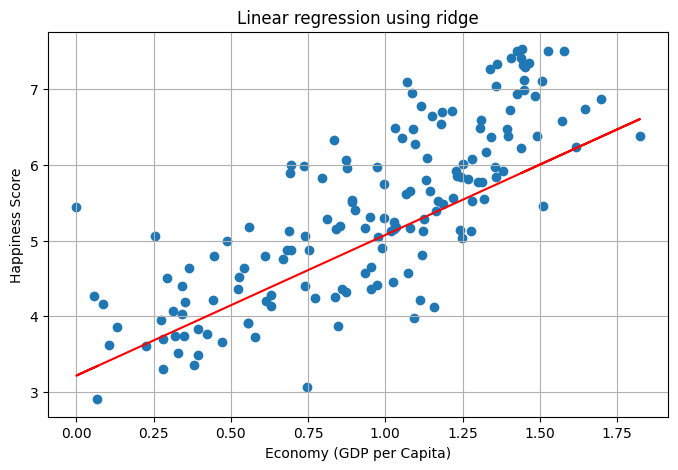

In [22]:
from lasso import Linear_Regression_Lasso

X = df['Economy (GDP per Capita)'].to_numpy()
y = df['Happiness Score'].to_numpy()

ridge = Linear_Regression_Lasso()
ridge.fit(X, y, alpha=1.5, max_iters=10, lr=0.1, stats=False)

y_pred = ridge.predict(X)

print(f'Final RMSE:\n{RMSE(y, y_pred)}')
print(f'Final function:\ny = {ridge.weights}X + {ridge.bias}')

plt.figure(figsize=(8, 5))
plt.scatter(X, y, label='Data')
plt.plot(X, y_pred, color='red', label='Closed form')
plt.grid(True)
plt.title('Linear regression using ridge') 
plt.xlabel('Economy (GDP per Capita)')
plt.ylabel('Happiness Score')

---

### **Polynomial regression**

Text(0.5, 1.0, 'Polynomial regression using mini-batch method')

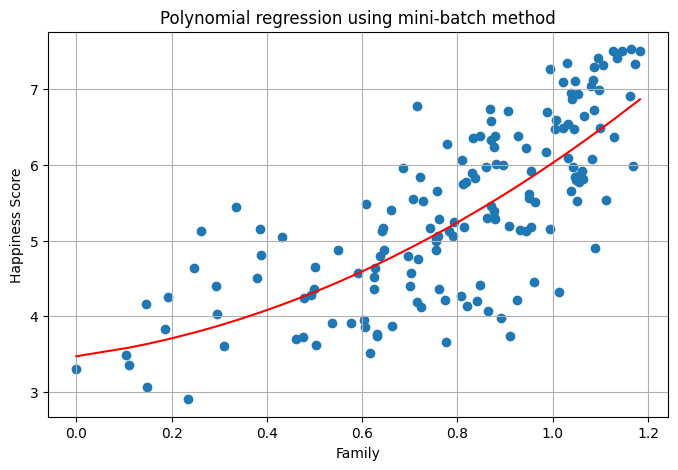

In [20]:
from polynomial_regression import Linear_Regression_Polynomial

X = df['Family'].to_numpy()
y = df['Happiness Score'].to_numpy()

polynomial = Linear_Regression_Polynomial()

X_poly = polynomial.transform(X, power=2)

mini_batch = Linear_Regression_Mini_Batch()

mini_batch.fit(X_poly, y, max_iters=100, lr=0.2, stats=False)
y_pred = mini_batch.predict(X_poly)


plt.figure(figsize=(8, 5))
plt.scatter(X, y)
sort_idx = np.argsort(X)
plt.plot(X[sort_idx], y_pred[sort_idx], color='red')
plt.grid()
plt.xlabel('Family')
plt.ylabel('Happiness Score')
plt.title('Polynomial regression using mini-batch method')

---

### **Time comparison**

In [21]:
import time
features = [
    'Economy (GDP per Capita)',
    'Family', 
    'Health (Life Expectancy)', 
    'Freedom',
    'Trust (Government Corruption)', 
    'Generosity',
    'Dystopia Residual'
]
algorithm = [
    'Closed form',
    'Gradient descent',
    'Stochastic gradient descent',
    'Mini-batch gradient descent',
    'Singular value decomposiotion',
    'Ridge'
]
X = df[features].to_numpy()
y = df['Happiness Score'].to_numpy()

cf = []
gd = []
sgd = []
batch = []
svd = []
ridge = []

for _ in range (10):
    start = time.time()
    regression = Linear_Regression_Closed_Form()
    regression.fit(X, y)
    end = time.time()
    cf.append(end - start)

    start = time.time()
    regression = Linear_Regression_Gradient()
    regression.fit(X, y, max_iters=10, lr=0.4)
    end = time.time()
    gd.append(end - start)

    start = time.time()
    regression = Linear_Regression_Stochastic_GD()
    regression.fit(X, y, max_iters=10, lr=0.4)
    end = time.time()
    sgd.append(end - start)

    start = time.time()
    regression = Linear_Regression_Mini_Batch()
    regression.fit(X, y, max_iters=10, lr=0.4)
    end = time.time()
    batch.append(end - start)

    start = time.time()
    regression = Linear_Regression_SVD()
    regression.fit(X, y)
    end = time.time()
    svd.append(end - start)

    start = time.time()
    regression = Linear_Regression_Ridge()
    regression.fit(X, y, alpha=0.2)
    end = time.time()
    ridge.append(end - start)

df_times = pd.DataFrame({
    'Algorithm' : algorithm,
    'Mean Time (s)': [
        np.mean(cf),
        np.mean(gd),
        np.mean(sgd),
        np.mean(batch),
        np.mean(svd),
        np.mean(ridge)
    ]
})

df_times

c:\Users\pando\Desktop\ML_AI\machine_learning_from_scratch\01_linear_regression\stochastic_gd.py:53: RuntimeWarning: overflow encountered in matmul
  dw = 2 * Xi.T @ error
c:\Users\pando\Desktop\ML_AI\machine_learning_from_scratch\01_linear_regression\stochastic_gd.py:54: RuntimeWarning: overflow encountered in scalar multiply
  db = 2 * np.sum(error)
c:\Users\pando\Desktop\ML_AI\machine_learning_from_scratch\01_linear_regression\stochastic_gd.py:56: RuntimeWarning: invalid value encountered in subtract
  self.weights = self.weights - (lr * dw)
c:\Users\pando\Desktop\ML_AI\machine_learning_from_scratch\01_linear_regression\stochastic_gd.py:57: RuntimeWarning: invalid value encountered in scalar subtract
  self.bias = self.bias - (lr * db)


,Algorithm,Mean Time (s)
0,Closed form,0.000028
1,Gradient descent,0.000094
2,Stochastic gradient descent,0.011520
3,Mini-batch gradient descent,0.000520
4,Singular value decomposiotion,0.000096
5,Ridge,0.000032


---